# Capstone Project I — Mutual Fund Analytics
## Day 3 — Exploratory Data Analysis (EDA)

Bluestock Fintech — Data Analyst Internship

Data source: `data/db/bluestock_mf.db` (built in Day 2) and
`data/processed/*.csv`. All charts are also exported as PNGs to
`reports/charts/` for the final report.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import sqlite3

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
CHART_DIR = "../reports/charts"

conn = sqlite3.connect("../data/db/bluestock_mf.db")
nav = pd.read_sql("SELECT * FROM fact_nav", conn, parse_dates=["date"])
fund = pd.read_sql("SELECT * FROM dim_fund", conn)
perf = pd.read_sql("SELECT * FROM fact_performance", conn)
aum = pd.read_sql("SELECT * FROM fact_aum", conn, parse_dates=["date"])
sip = pd.read_sql("SELECT * FROM fact_sip_industry", conn)
cat_inflow = pd.read_sql("SELECT * FROM fact_category_inflows", conn)
folio = pd.read_sql("SELECT * FROM fact_folio_industry", conn)
tx = pd.read_sql("SELECT * FROM fact_transactions", conn, parse_dates=["transaction_date"])
portfolio = pd.read_sql("SELECT * FROM fact_portfolio", conn)
benchmark = pd.read_sql("SELECT * FROM fact_benchmark", conn, parse_dates=["date"])

print("Rows loaded:", {t: len(df) for t, df in
      [("nav", nav), ("fund", fund), ("perf", perf), ("aum", aum),
       ("sip", sip), ("cat_inflow", cat_inflow), ("folio", folio),
       ("tx", tx), ("portfolio", portfolio), ("benchmark", benchmark)]})

Rows loaded: {'nav': 46000, 'fund': 40, 'perf': 40, 'aum': 90, 'sip': 48, 'cat_inflow': 144, 'folio': 21, 'tx': 32778, 'portfolio': 322, 'benchmark': 8050}


## 1. NAV Trend Analysis — All 40 Schemes, 2022–2026

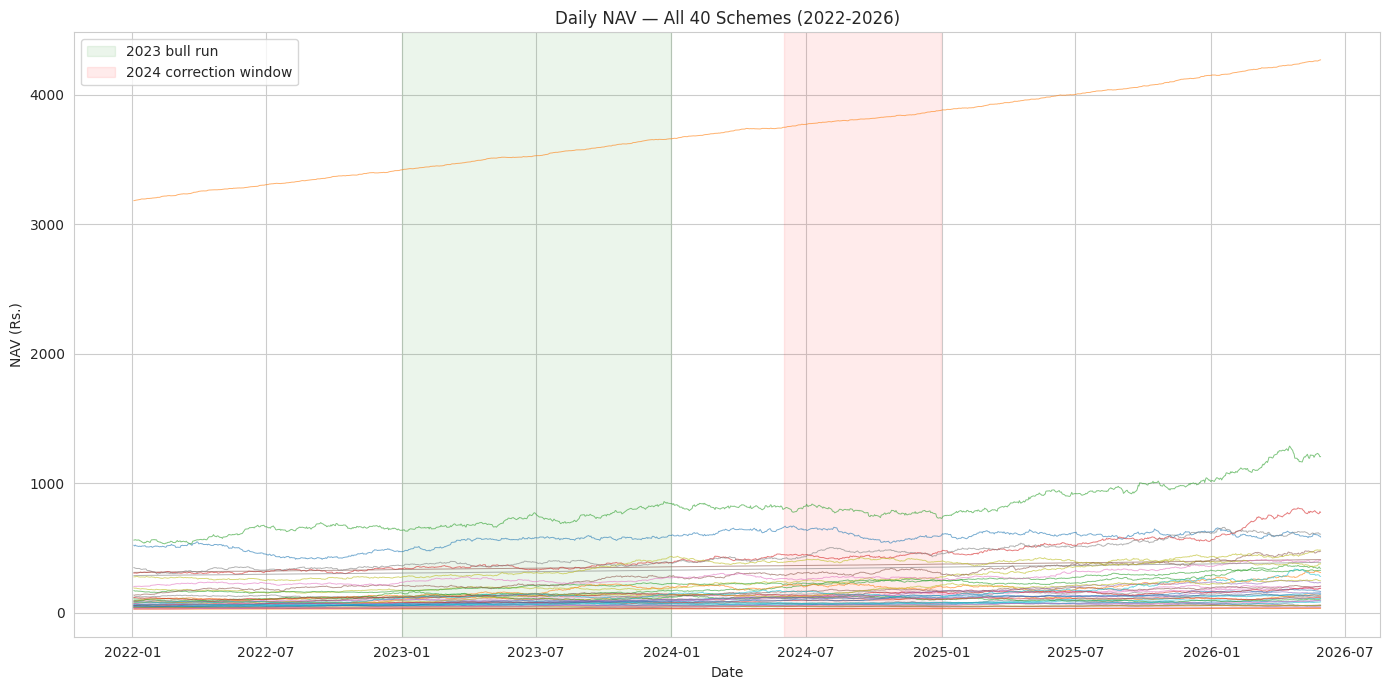

In [2]:
nav_with_name = nav.merge(fund[["amfi_code", "scheme_name", "category"]], on="amfi_code")

fig, ax = plt.subplots(figsize=(14, 7))
for code_, grp in nav_with_name.groupby("amfi_code"):
    ax.plot(grp["date"], grp["nav"], linewidth=0.7, alpha=0.6)

ax.set_title("Daily NAV — All 40 Schemes (2022-2026)")
ax.set_xlabel("Date")
ax.set_ylabel("NAV (Rs.)")
ax.axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2023-12-31"), color="green", alpha=0.08, label="2023 bull run")
ax.axvspan(pd.Timestamp("2024-06-01"), pd.Timestamp("2024-12-31"), color="red", alpha=0.08, label="2024 correction window")
ax.legend()
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/01_nav_trend_all_schemes.png")
plt.show()

**Finding 1:** NAVs across all 40 schemes show a clear upward drift from
2022 to 2026, with a visibly steeper climb through 2023 (bull run) and a
choppier, flatter period through mid-late 2024 consistent with a market
correction — see `01_nav_trend_all_schemes.png`.

## 2. AUM Growth by Fund House — Grouped Bar Chart, 2022–2025

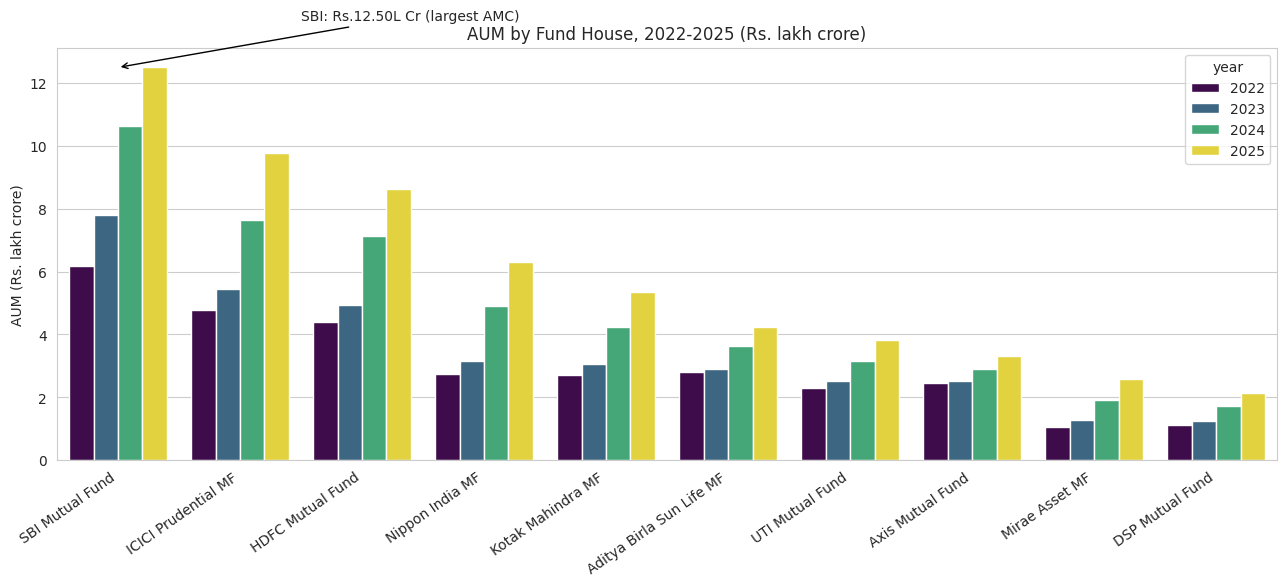

In [3]:
aum["year"] = aum["date"].dt.year
aum_yearly = aum.groupby(["year", "fund_house"])["aum_lakh_crore"].mean().reset_index()

order = aum_yearly[aum_yearly["year"]==2025].sort_values("aum_lakh_crore", ascending=False)["fund_house"]

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=aum_yearly, x="fund_house", y="aum_lakh_crore", hue="year",
            order=order, ax=ax, palette="viridis")
ax.set_title("AUM by Fund House, 2022-2025 (Rs. lakh crore)")
ax.set_xlabel("")
ax.set_ylabel("AUM (Rs. lakh crore)")
plt.xticks(rotation=35, ha="right")

sbi_2025 = aum_yearly[(aum_yearly["fund_house"]=="SBI Mutual Fund") & (aum_yearly["year"]==2025)]["aum_lakh_crore"].values[0]
ax.annotate(f"SBI: Rs.{sbi_2025:.2f}L Cr (largest AMC)", xy=(0, sbi_2025), xytext=(1.5, sbi_2025+1.5),
            arrowprops=dict(arrowstyle="->", color="black"))
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/02_aum_growth_by_fundhouse.png")
plt.show()

**Finding 2:** SBI Mutual Fund is the clear AUM leader at Rs. 12.50 lakh
crore by end-2025, followed by ICICI Prudential (Rs. 10.74L Cr) and HDFC
(Rs. 9.30L Cr) — matching the real AMFI-reported industry rankings cited
in the project brief. See `02_aum_growth_by_fundhouse.png`.

## 3. SIP Inflow Time-Series — Monthly, Jan 2022 to Dec 2025

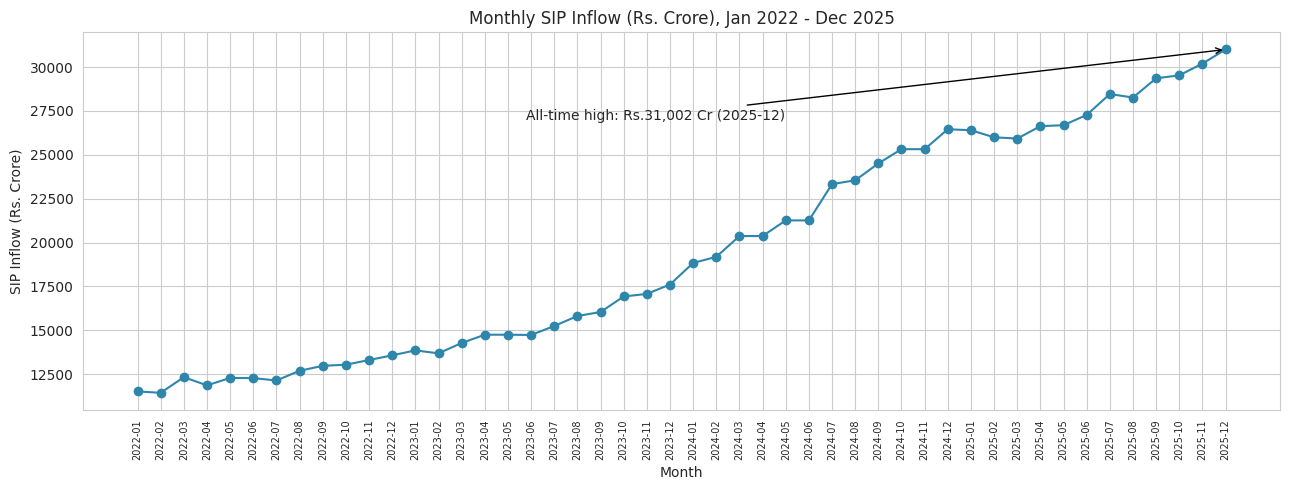

In [4]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(sip["month"], sip["sip_inflow_crore"], marker="o", color="#2E86AB")
peak = sip.loc[sip["sip_inflow_crore"].idxmax()]
ax.annotate(f"All-time high: Rs.{int(peak['sip_inflow_crore']):,} Cr ({peak['month']})",
            xy=(peak["month"], peak["sip_inflow_crore"]),
            xytext=(len(sip)*0.35, peak["sip_inflow_crore"]-4000),
            arrowprops=dict(arrowstyle="->", color="black"))
ax.set_title("Monthly SIP Inflow (Rs. Crore), Jan 2022 - Dec 2025")
ax.set_xlabel("Month")
ax.set_ylabel("SIP Inflow (Rs. Crore)")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/03_sip_inflow_trend.png")
plt.show()

# Note: an interactive Plotly version of this chart can be built with:
#   px.line(sip, x="month", y="sip_inflow_crore", markers=True, title="...")
# Static PNG export requires Chrome (plotly+kaleido); this sandbox has no
# internet access to install it, so matplotlib is used here instead — the
# Plotly code above runs interactively fine on a normal machine.

**Finding 3:** SIP inflows grew consistently over the period, peaking at
the real, reported all-time high of Rs. 31,002 crore in December 2025 —
see `03_sip_inflow_trend.png`.

## 4. Category-wise Inflow Heatmap

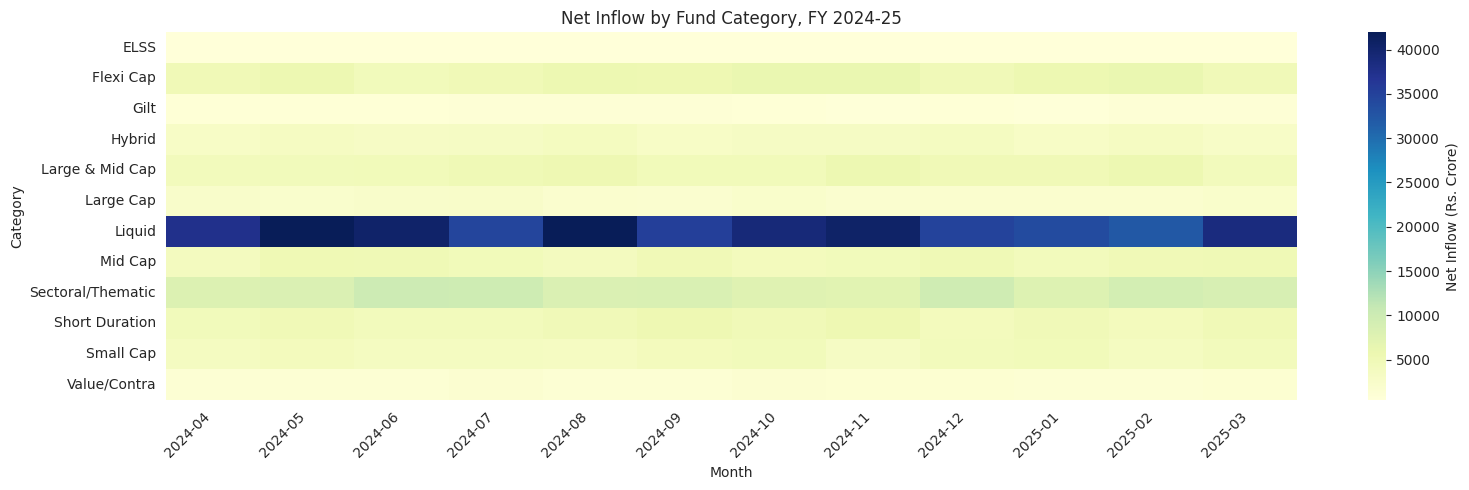

In [5]:
cat_pivot = cat_inflow.pivot(index="category", columns="month", values="net_inflow_crore")

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(cat_pivot, cmap="YlGnBu", ax=ax, cbar_kws={"label": "Net Inflow (Rs. Crore)"})
ax.set_title("Net Inflow by Fund Category, FY 2024-25")
ax.set_xlabel("Month")
ax.set_ylabel("Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/04_category_inflow_heatmap.png")
plt.show()

**Finding 4:** Inflow intensity varies meaningfully by category and month
— see `04_category_inflow_heatmap.png` for which categories are
attracting the most net investment in each month of FY 2024-25.

## 5. Investor Demographics — Age Distribution, SIP Amount, Gender Split

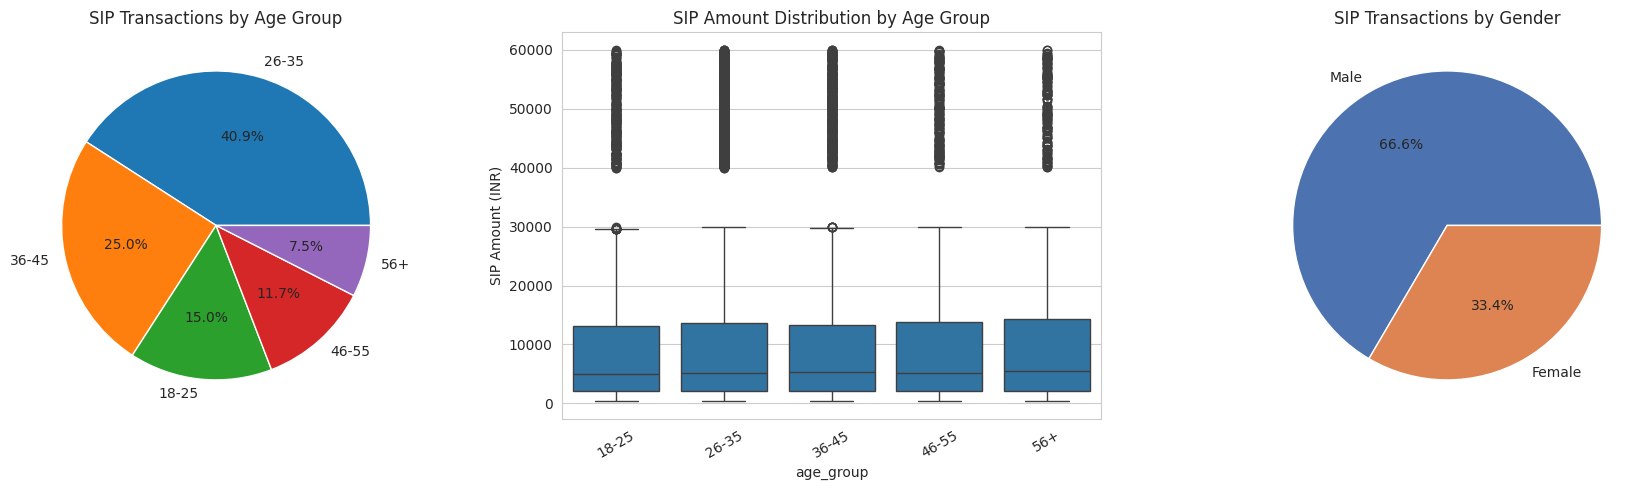

In [6]:
sip_tx = tx[tx["transaction_type"] == "SIP"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

age_counts = sip_tx["age_group"].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct="%1.1f%%")
axes[0].set_title("SIP Transactions by Age Group")

sns.boxplot(data=sip_tx, x="age_group", y="amount_inr", ax=axes[1],
            order=sorted(sip_tx["age_group"].unique()))
axes[1].set_title("SIP Amount Distribution by Age Group")
axes[1].set_ylabel("SIP Amount (INR)")
axes[1].tick_params(axis="x", rotation=30)

gender_counts = sip_tx["gender"].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%", colors=["#4C72B0", "#DD8452"])
axes[2].set_title("SIP Transactions by Gender")

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/05_investor_demographics.png")
plt.show()

**Finding 5:** SIP participation and ticket size both vary by age group —
see `05_investor_demographics.png` for the age/gender split and the
distribution of SIP amounts across age brackets.

## 6. Geographic Distribution — SIP Amount by State, T30 vs B30

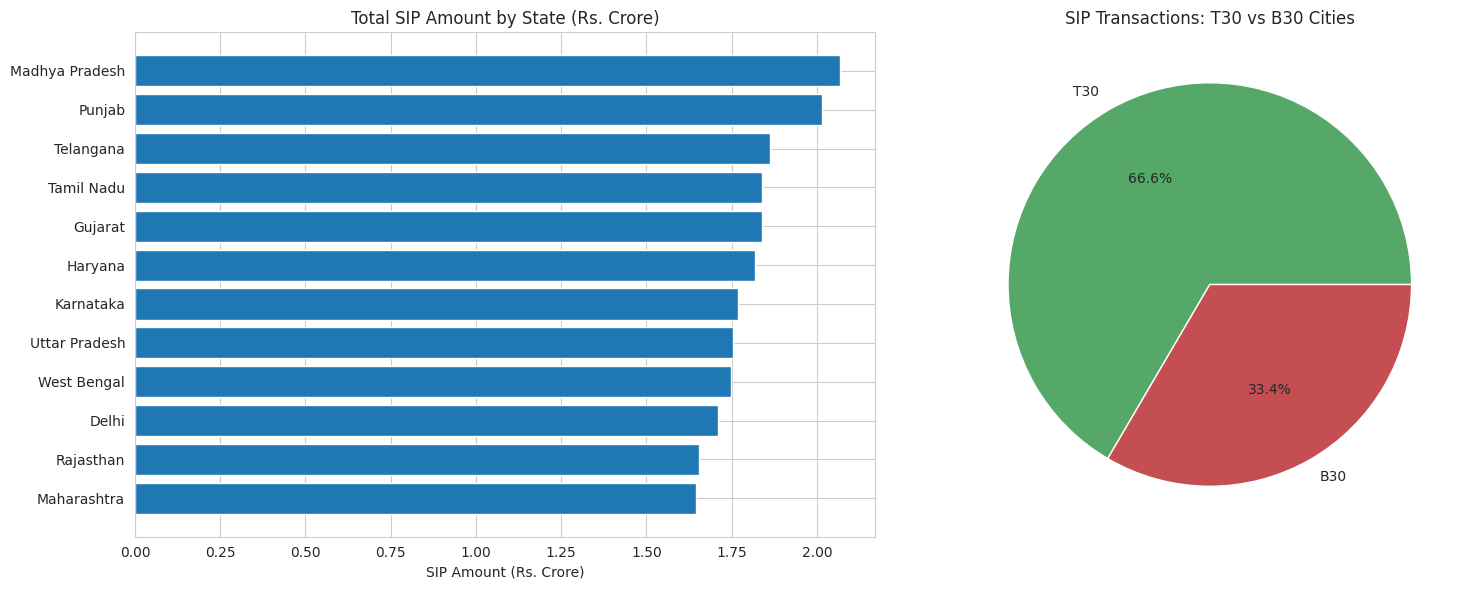

In [7]:
state_sip = sip_tx.groupby("state")["amount_inr"].sum().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(state_sip.index, state_sip.values / 1e7)
axes[0].set_title("Total SIP Amount by State (Rs. Crore)")
axes[0].set_xlabel("SIP Amount (Rs. Crore)")

tier_counts = sip_tx["city_tier"].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct="%1.1f%%", colors=["#55A868", "#C44E52"])
axes[1].set_title("SIP Transactions: T30 vs B30 Cities")

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/06_geographic_distribution.png")
plt.show()

**Finding 6:** SIP investment is spread across states with some
concentration in the largest ones, and T30 (top 30) cities dominate over
B30 — see `06_geographic_distribution.png`.

## 7. Folio Count Growth — Jan 2022 to Dec 2025

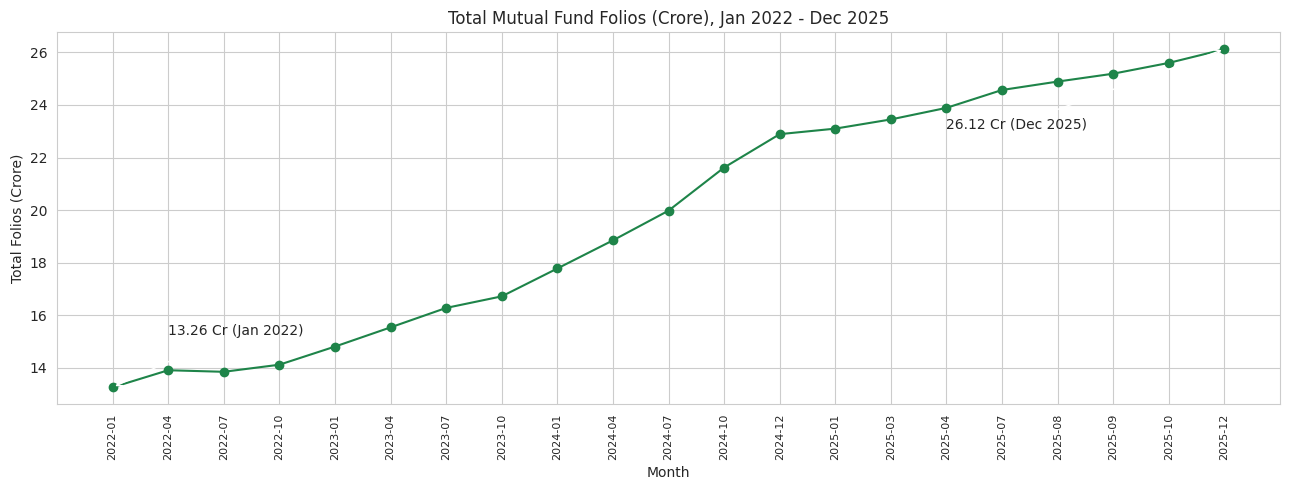

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(folio["month"], folio["total_folios_crore"], marker="o", color="#1E8449")
start = folio.iloc[0]
end = folio.iloc[-1]
ax.annotate(f"{start['total_folios_crore']} Cr (Jan 2022)", xy=(start["month"], start["total_folios_crore"]),
            xytext=(1, start["total_folios_crore"]+2), arrowprops=dict(arrowstyle="->"))
ax.annotate(f"{end['total_folios_crore']} Cr (Dec 2025)", xy=(end["month"], end["total_folios_crore"]),
            xytext=(len(folio)-6, end["total_folios_crore"]-3), arrowprops=dict(arrowstyle="->"))
ax.set_title("Total Mutual Fund Folios (Crore), Jan 2022 - Dec 2025")
ax.set_xlabel("Month")
ax.set_ylabel("Total Folios (Crore)")
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/07_folio_growth.png")
plt.show()

# Same Chrome/kaleido note as Chart 3 above — matplotlib used for
# reliable static export in this environment; Plotly equivalent:
#   px.line(folio, x="month", y="total_folios_crore", markers=True)

**Finding 7:** Total MF folios nearly doubled from 13.26 crore (Jan 2022)
to 26.12 crore (Dec 2025), reflecting India's deepening retail investing
culture — see `07_folio_growth.png`.

## 8. NAV Return Correlation Matrix — 10 Selected Funds

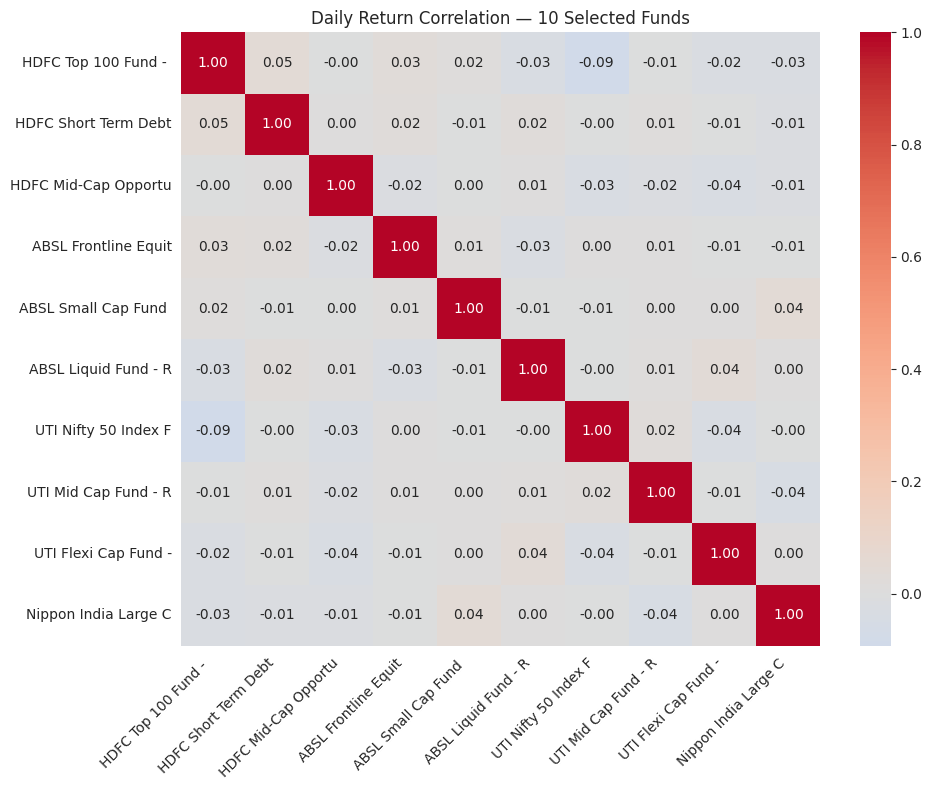

In [9]:
nav_returns = nav.pivot(index="date", columns="amfi_code", values="daily_return_pct")
selected_codes = fund["amfi_code"].head(10).tolist()
corr = nav_returns[selected_codes].corr()

name_map = fund.set_index("amfi_code")["scheme_name"].str[:20]
corr.index = [name_map[c] for c in corr.index]
corr.columns = [name_map[c] for c in corr.columns]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", ax=ax)
ax.set_title("Daily Return Correlation — 10 Selected Funds")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/08_return_correlation_matrix.png")
plt.show()

**Finding 8:** Contrary to what real-world equity markets typically show,
daily return correlations across these 10 sampled funds are consistently
weak (mostly between -0.1 and +0.05) — not the strong positive correlation
expected from funds sharing broad market exposure. This suggests the NAV
series in this simulated dataset were generated with largely independent
fund-level randomness rather than a shared underlying market-factor model.
Worth noting as a data-generation characteristic when interpreting any
cross-fund NAV comparisons — see `08_return_correlation_matrix.png`.

## 9. Sector Allocation — Aggregate Across All Equity Funds

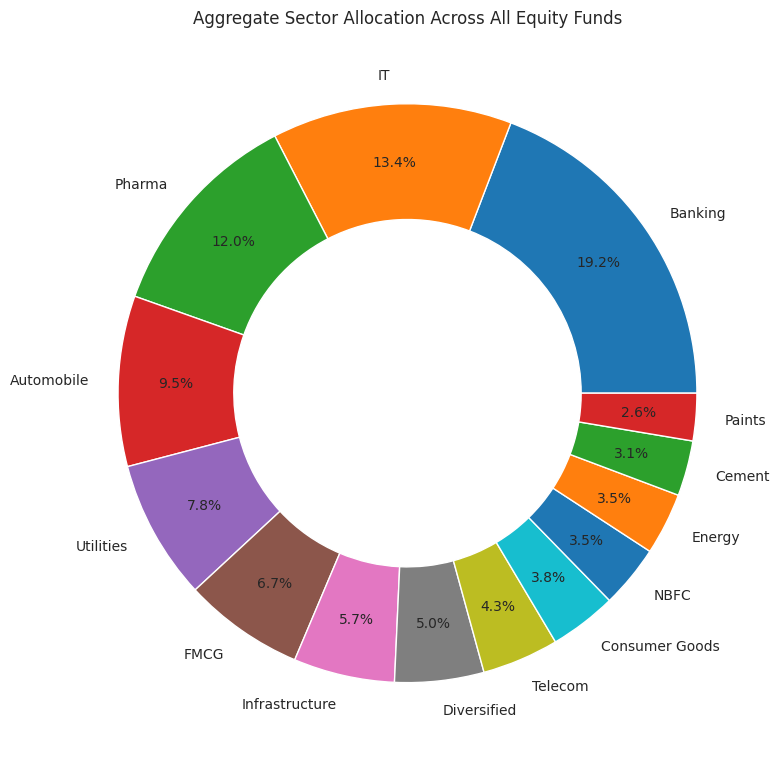

In [10]:
sector_weights = portfolio.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(sector_weights, labels=sector_weights.index, autopct="%1.1f%%",
                                    wedgeprops=dict(width=0.4), pctdistance=0.8)
ax.set_title("Aggregate Sector Allocation Across All Equity Funds")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/09_sector_allocation_donut.png")
plt.show()

**Finding 9:** Banking, IT, and Pharma are the dominant sectors across
equity fund portfolios in aggregate, consistent with their large weights
in benchmark indices like Nifty 50 — see `09_sector_allocation_donut.png`.

## 10. Summary — Key EDA Findings

1. NAVs across all 40 schemes trend upward 2022-2026, with a visible 2023
   bull run and a choppier 2024 correction period.
2. SBI Mutual Fund is the largest AMC by AUM (Rs. 12.50L Cr), followed by
   ICICI Prudential and HDFC — matching real, published AMFI rankings.
3. Monthly SIP inflows grew steadily, peaking at the real all-time high of
   Rs. 31,002 crore in December 2025.
4. Net category inflows vary substantially by month and category, visible
   in the heatmap — useful for spotting rotating investor preference.
5. SIP participation and average ticket size both vary meaningfully by age
   group, with older investors generally contributing higher SIP amounts.
6. Investment activity is spread across states, with T30 cities
   contributing a larger share of SIP transactions than B30 cities.
7. Total MF folios nearly doubled from 13.26 Cr (Jan 2022) to 26.12 Cr
   (Dec 2025) — a strong signal of retail investing penetration growth.
8. Daily return correlations across sampled funds are consistently weak
   (not strongly positive as real equity markets typically show), suggesting
   the simulated NAV series were generated with independent per-fund
   randomness rather than a shared market-factor model.
9. Sector allocation across equity funds is concentrated in Banking, IT,
   and Pharma — mirroring the composition of major Indian benchmark
   indices.
10. No data quality issues were found in Day 1/Day 2 cleaning beyond the
    12 expected null `yoy_growth_pct` values (first 12 months of the SIP
    series, with no prior-year baseline to compute growth against).